### Importation

In [ ]:
import copy
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import scipy
import missingno
import miceforest as mf
import utils


### 2. Data Collection

In [2]:
path = "gs://data-epip/train/paysim.parquet"
train_pdf = pd.read_parquet(path, engine='pyarrow')
train_pdf.drop(["nameOrig", "nameDest", "step"], axis=1, inplace=True)
train_pdf.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,isFraud
5078311,CASH_OUT,56964.57,20090.00,0.00,0.00,56964.57,0,0
3910779,CASH_OUT,108454.37,505.00,0.00,0.00,108454.37,0,0
5412246,CASH_OUT,467324.33,1634.00,0.00,258071.61,725395.95,0,0
1086881,CASH_IN,274154.97,3171570.20,3445725.17,1692712.58,987166.60,0,0
2800286,PAYMENT,31158.42,23231.09,0.00,0.00,0.00,0,0


In [3]:
train_pdf.shape

(5408227, 8)

### 3. Data Preparation 

###### Contrôler le type des colonnes et changer si nécessaire

In [4]:
train_pdf["type"] = train_pdf["type"].astype("category")
train_pdf["isFraud"] = train_pdf["isFraud"].astype("category")
train_pdf["isFlaggedFraud"] = train_pdf["isFlaggedFraud"].astype("category")
train_pdf.info()

<class 'pandas.DataFrame'>
Index: 5408227 entries, 5078311 to 1541412
Data columns (total 8 columns):
 #   Column          Dtype   
---  ------          -----   
 0   type            category
 1   amount          float64 
 2   oldbalanceOrg   float64 
 3   newbalanceOrig  float64 
 4   oldbalanceDest  float64 
 5   newbalanceDest  float64 
 6   isFlaggedFraud  category
 7   isFraud         category
dtypes: category(3), float64(5)
memory usage: 263.0 MB


###### Consistance des données de type catégoriel

In [5]:
category_data = train_pdf.select_dtypes(include="category")

pd.DataFrame({"Information sur les variables catégorielles": category_data.apply(lambda x:x.unique().tolist() , axis =0)})

,Information sur les variables catégorielles
type,"[CASH_OUT, CASH_IN, PAYMENT, TRANSFER, DEBIT]"
isFlaggedFraud,"[0, 1]"
isFraud,"[0, 1]"


###### skweness

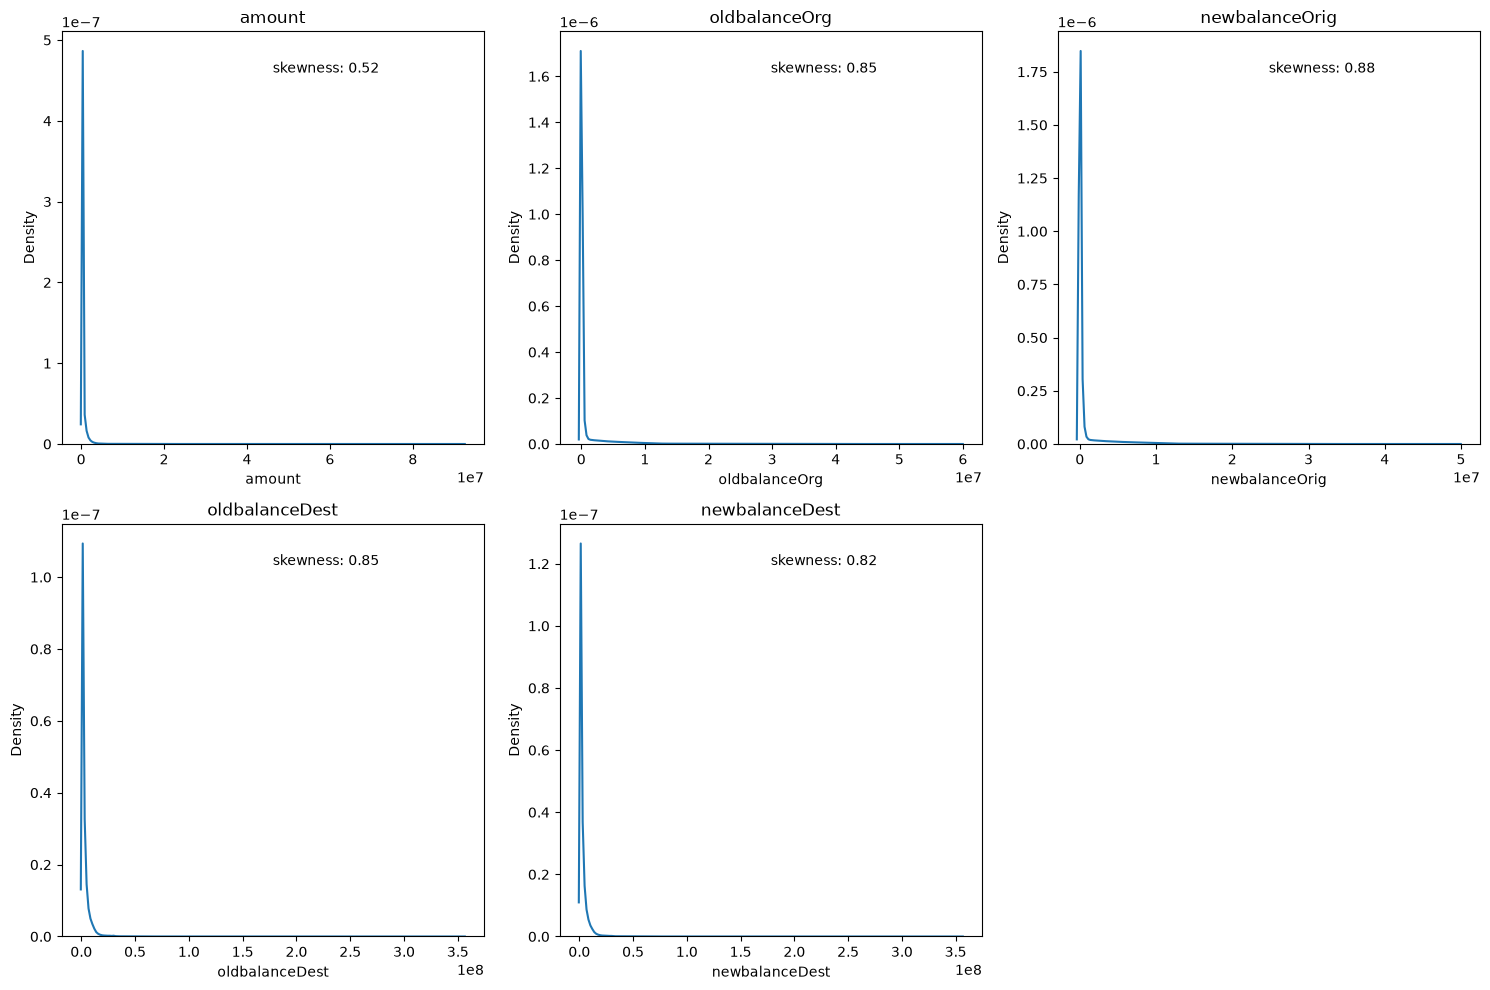

In [6]:
df = train_pdf.select_dtypes(include=["float", "int"])
col = df.columns.tolist()

fig = plt.figure(figsize=(15,10))
for i in range(len(col)):
    plt.subplot(2,3,i+1)
    plt.title(col[i])
    sns.kdeplot(data=df, x=col[i])
    plt.text(0.5, 0.9, f'skewness: {utils.pearson_skewness(df[col[i]]):.2f}', transform=plt.gca().transAxes)
plt.tight_layout()
plt.show()

del df


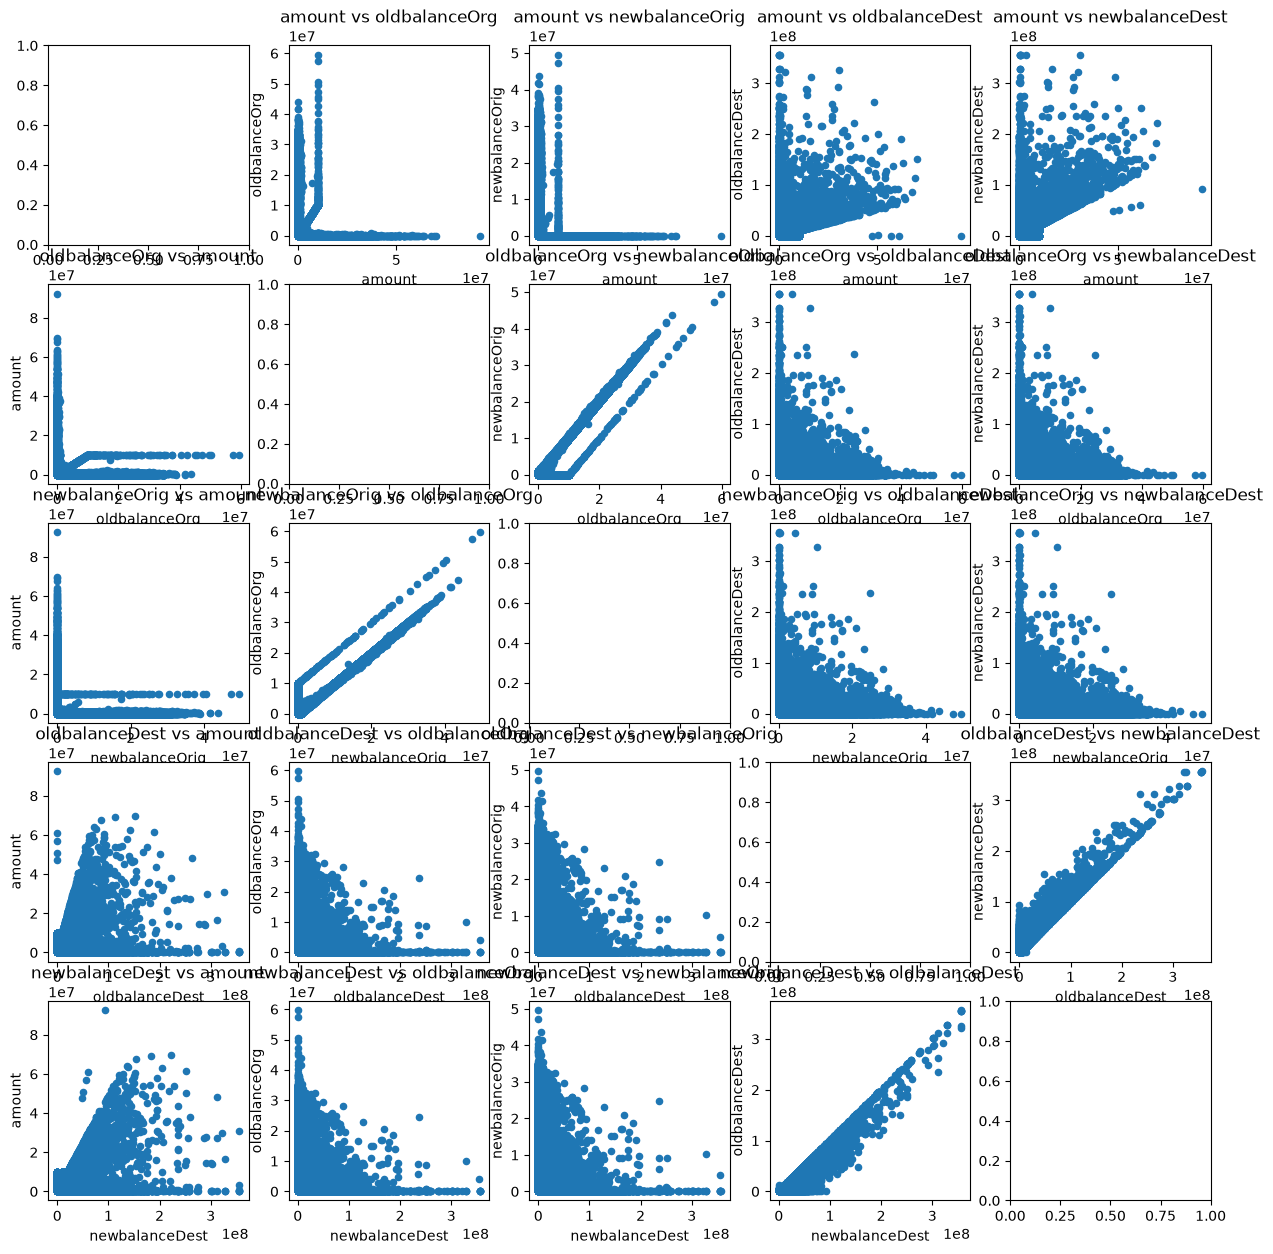

In [7]:
plt.rcParams['figure.figsize'] = (15, 15)
cols = train_pdf.select_dtypes(include=["int", "float"]).columns.tolist()

i = 1
for col in cols:
    for col_1 in cols:
        ax = plt.subplot(5, 5, i)
        if col_1 != col:
            fig = train_pdf.select_dtypes(include=["int", "float"]).plot(kind="scatter", x=col, y=col_1, ax=ax)
            plt.title(f"{col} vs {col_1}")
        else:
            pass
        i += 1

In [8]:
for col in train_pdf.select_dtypes(include=["int", "float"]).columns.tolist():
        train_pdf[col] = scipy.stats.boxcox(train_pdf[col]+1)[0]

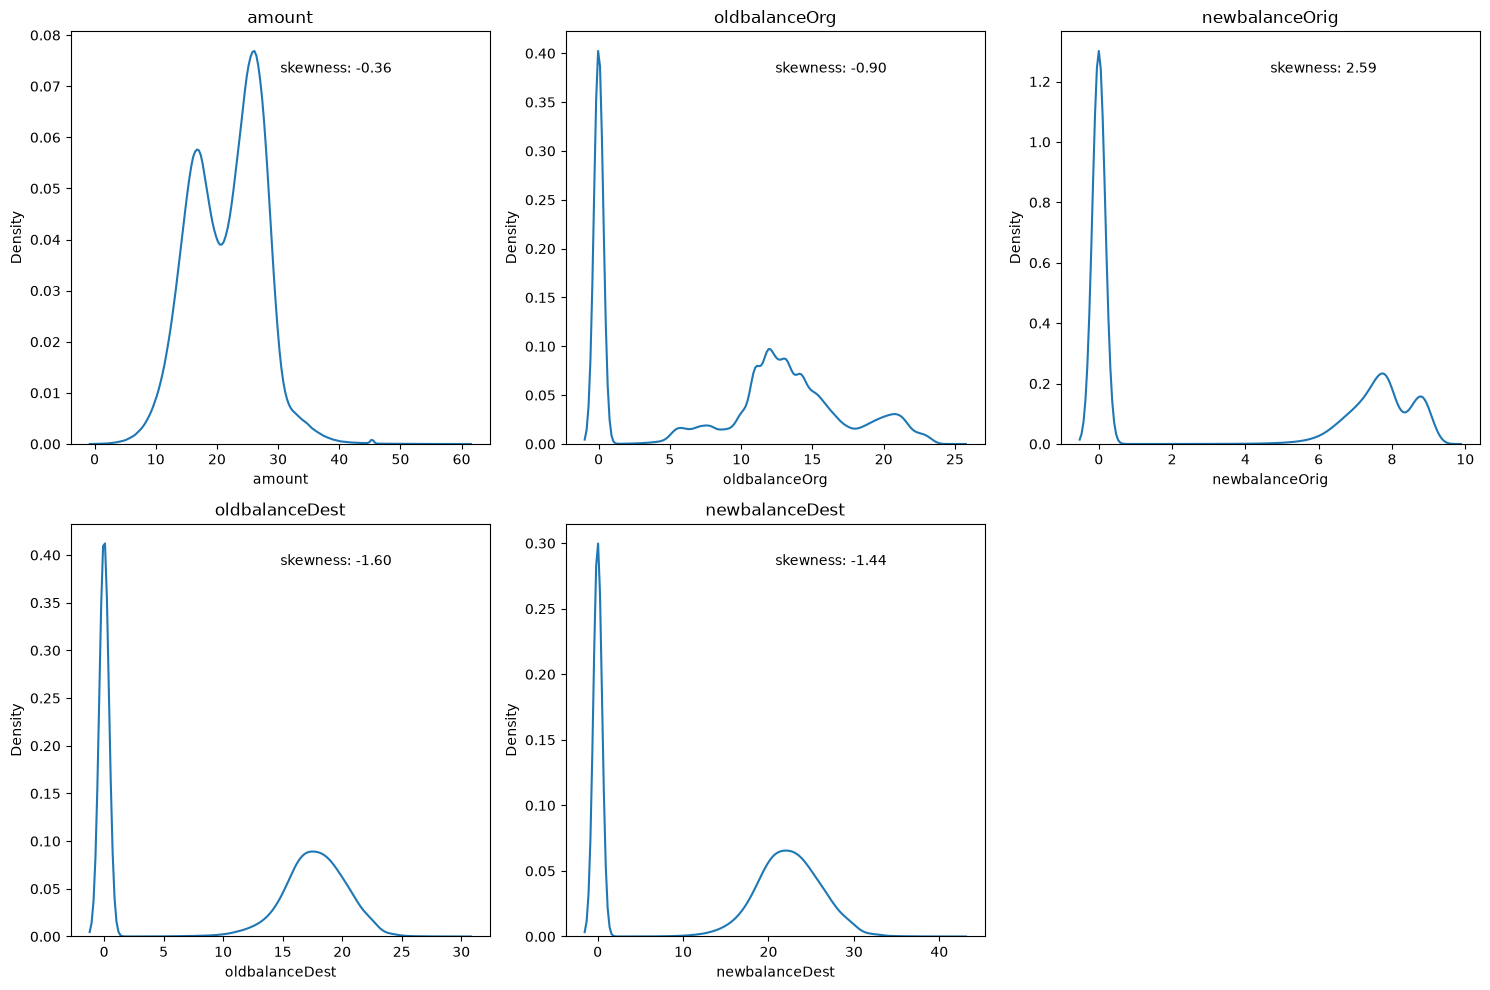

In [9]:
df = train_pdf.select_dtypes(include=["float", "int"])
col = df.columns.tolist()


fig = plt.figure(figsize=(15,10))
for i in range(len(col)):
    plt.subplot(2,3,i+1)
    plt.title(col[i])
    sns.kdeplot(data=df, x=col[i])
    plt.text(0.5, 0.9, f'skewness: {utils.pearson_skewness(df[col[i]]):.2f}', transform=plt.gca().transAxes)
plt.tight_layout()
plt.show()

del df

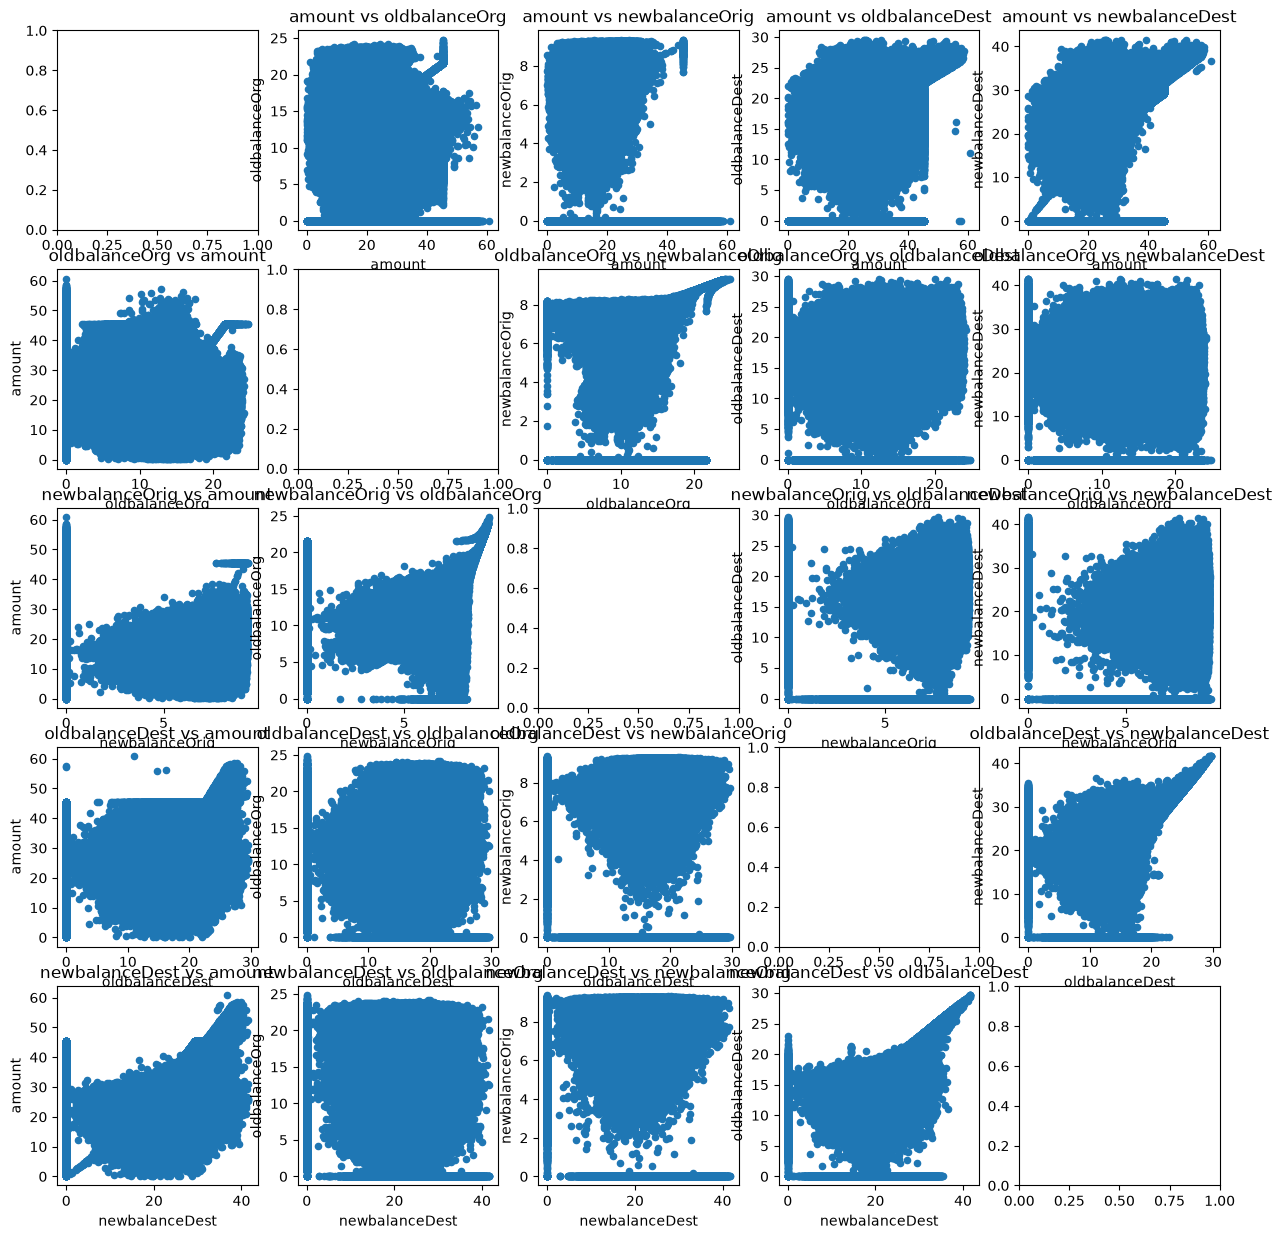

In [10]:
plt.rcParams['figure.figsize'] = (15, 15)
cols = train_pdf.select_dtypes(include=["int", "float"]).columns.tolist()


i = 1
for col in cols:
    for col_1 in cols:
        ax = plt.subplot(5, 5, i)
        if col_1 != col:
            fig = train_pdf.select_dtypes(include=["int", "float"]).plot(kind="scatter", x=col, y=col_1, ax=ax)
            plt.title(f"{col} vs {col_1}")
        else:
            pass
        i += 1

###### Problème d'échelle

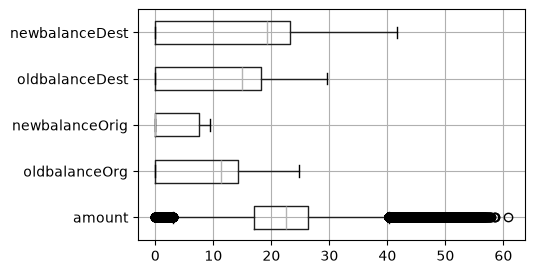

In [11]:
fig = train_pdf.select_dtypes(exclude=["str", "category", "object"]).boxplot(figsize=(5, 3), rot=0, vert=False, showfliers=True)

In [12]:
for col in train_pdf.select_dtypes(include=["int", "float"]).columns.tolist():
        train_pdf[col] = (train_pdf[col]-train_pdf[col].min()) / (train_pdf[col].max()-train_pdf[col].min())

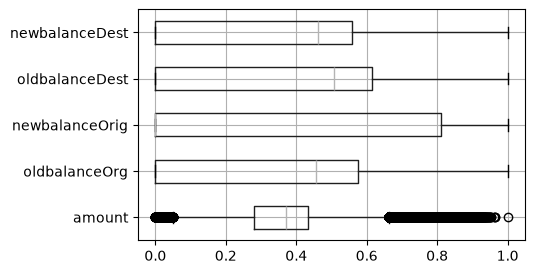

In [13]:
fig = train_pdf.select_dtypes(exclude=["str", "category", "object"]).boxplot(figsize=(5, 3), rot=0, vert=False, showfliers=True)

###### Outliers

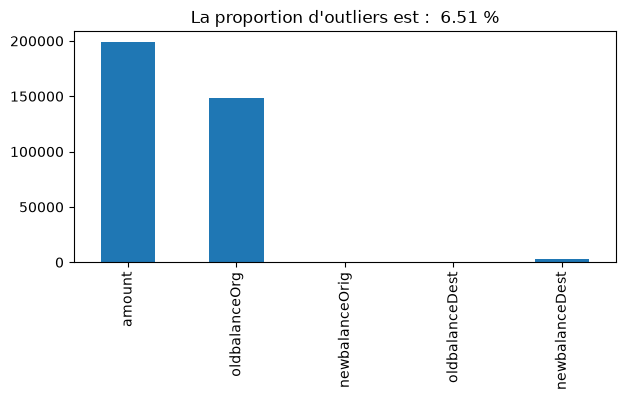

In [14]:
train_pdf_is_outliers = copy.deepcopy(train_pdf)

for col in train_pdf.select_dtypes(include=["int", "float"]).columns.tolist():
    train_pdf_is_outliers[col] = utils.borne_inf_sup(train_pdf[col])

plt.rcParams["figure.figsize"] = (7, 3)
plt.title(f"La proportion d'outliers est : {train_pdf_is_outliers.apply(lambda x: any(x==True) ,axis=1).sum()*100 / train_pdf_is_outliers.shape[0] : .2f} %")
fig = train_pdf_is_outliers.select_dtypes(exclude=["category", "object", "str"]).sum(axis=0).plot(kind="bar")
plt.show()

In [15]:
for col in train_pdf.select_dtypes(exclude=["category", "object", "str"]).columns.tolist():
    train_pdf.loc[utils.borne_inf_sup(train_pdf[col])==True, col] = np.nan

###### Gestion des données manquantes

In [16]:
train_pdf.isna().sum(axis = 0)

type                   0
amount            198796
oldbalanceOrg     148761
newbalanceOrig         0
oldbalanceDest       469
newbalanceDest      2793
isFlaggedFraud         0
isFraud                0
dtype: int64

<Axes: >

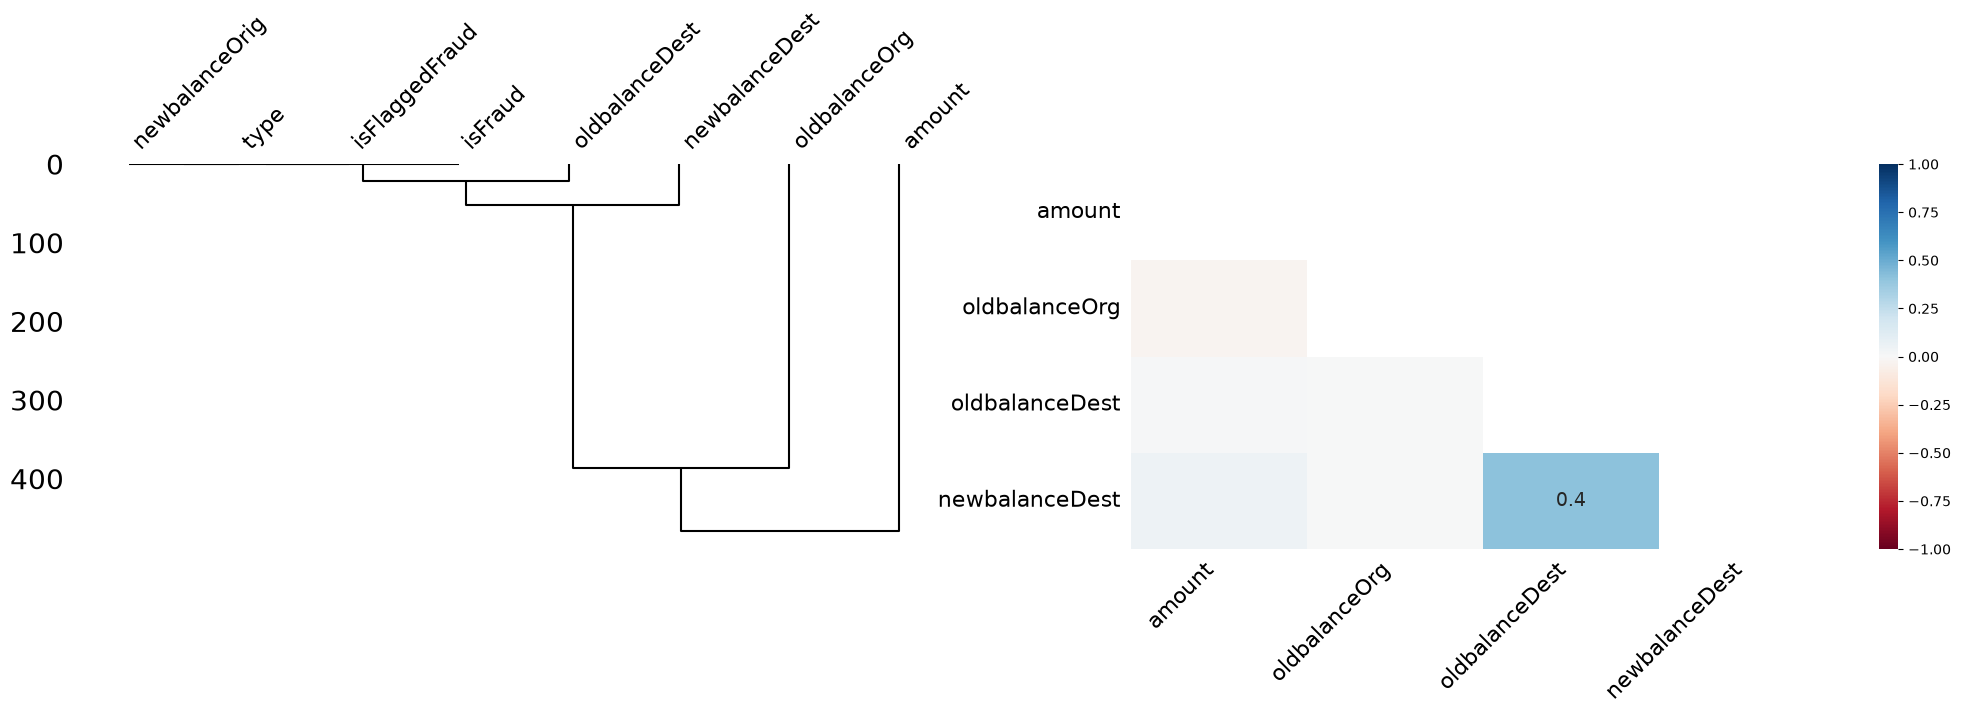

In [17]:
plt.rcParams['figure.figsize'] = (25, 5)
fig, (ax1, ax2) = plt.subplots(1, 2)
missingno.dendrogram(train_pdf, ax=ax1)

missingno.heatmap(train_pdf, ax=ax2)

In [18]:
# imputation MICE
original_index = train_pdf.index

train_pdf = train_pdf.reset_index(drop=True)
kernel = mf.ImputationKernel(
    train_pdf, num_datasets=1, save_all_iterations_data=True, random_state=42
)

kernel.mice(iterations=3)

train_pdf = kernel.complete_data(dataset=0)

train_pdf.index = original_index

In [19]:
train_pdf.isna().sum(axis=0)

type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFlaggedFraud    0
isFraud           0
dtype: int64

###### Vérifier que les proportions des variables catégorielles sont respectées

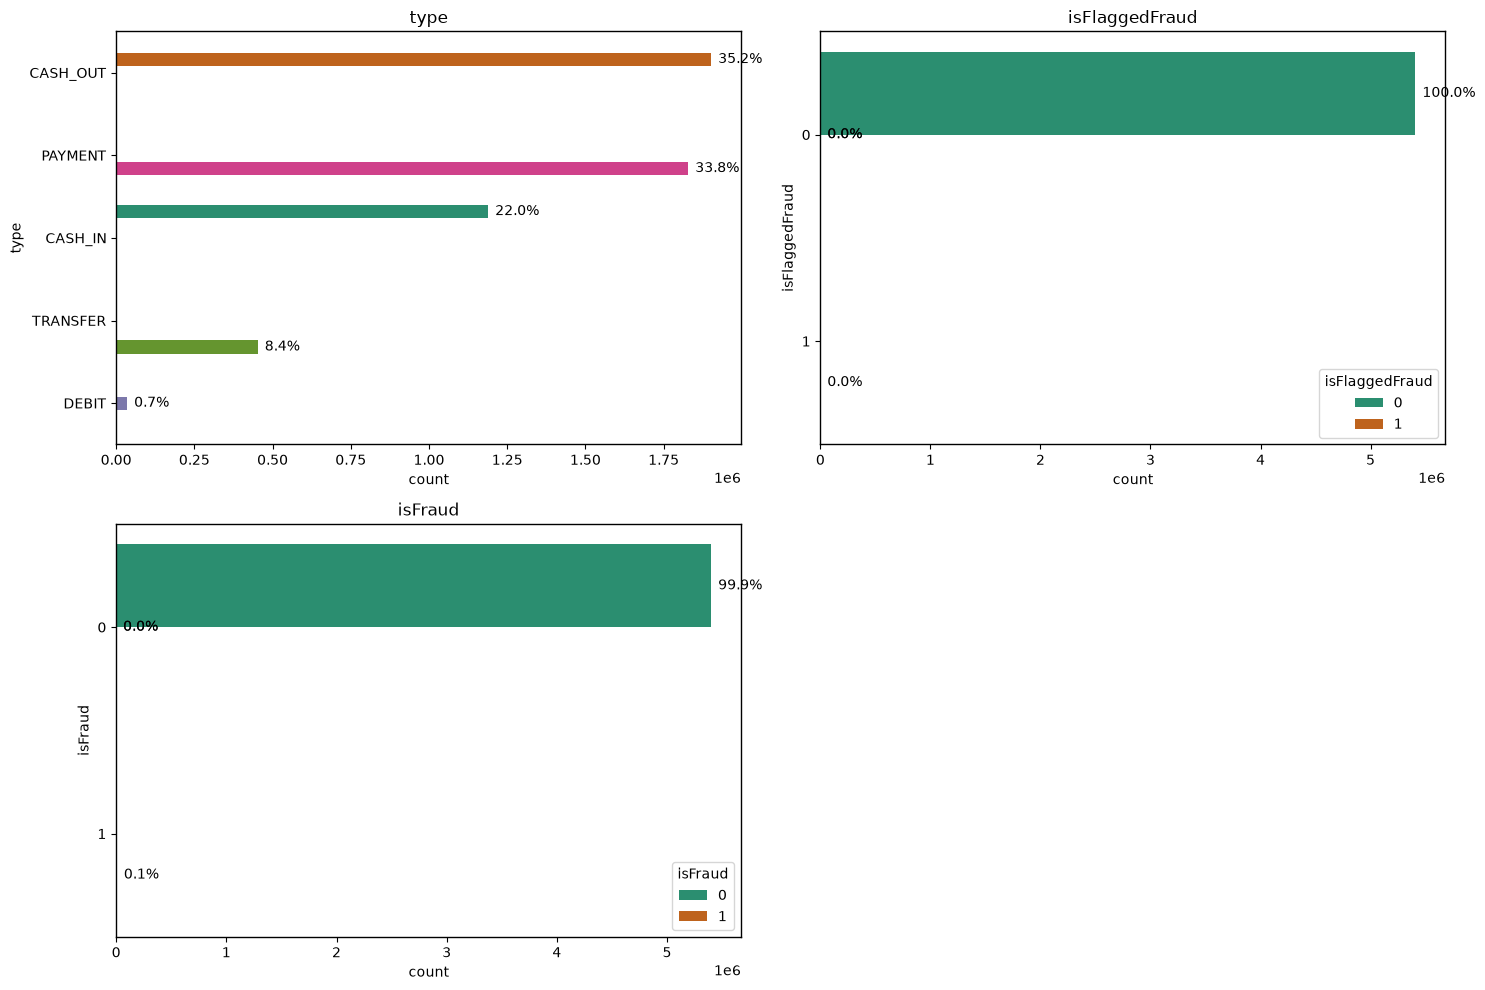

In [20]:
utils.plot_categorical(category_data)

# Solution 
# Regrouper les modalités très faibles
# Pour le target : utiliser des méthodes d'augmentation (imblearn.over_sampling.RandomOverSampler, SMOTE, ADASYN) ou d'undersampling

###### Etudes des corrélations 

<Axes: >

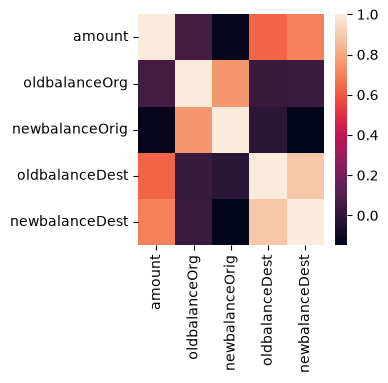

In [22]:
plt.rcParams["figure.figsize"] = (3, 3)
sns.heatmap(train_pdf.select_dtypes(include=["int", "float"]).corr(method='pearson'))